In [ ]:
!pip install geopandas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import networkx as nx
import plotly.graph_objects as go
import geopandas as gpd
import matplotlib.pyplot as plt
# Fix: Import cdist from scipy.spatial.distance instead of scipy.spatial
from scipy.spatial.distance import cdist
import mapclassify
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

In [2]:
# gdf = gpd.read_file("Eindhoven_map/FC_Nieghbourhood_Eindhoven.shp")
# print(gdf.columns)

In [20]:
import sys
sys.path.append("/home/WUR/katon002/.local/lib/python3.13/site-packages")

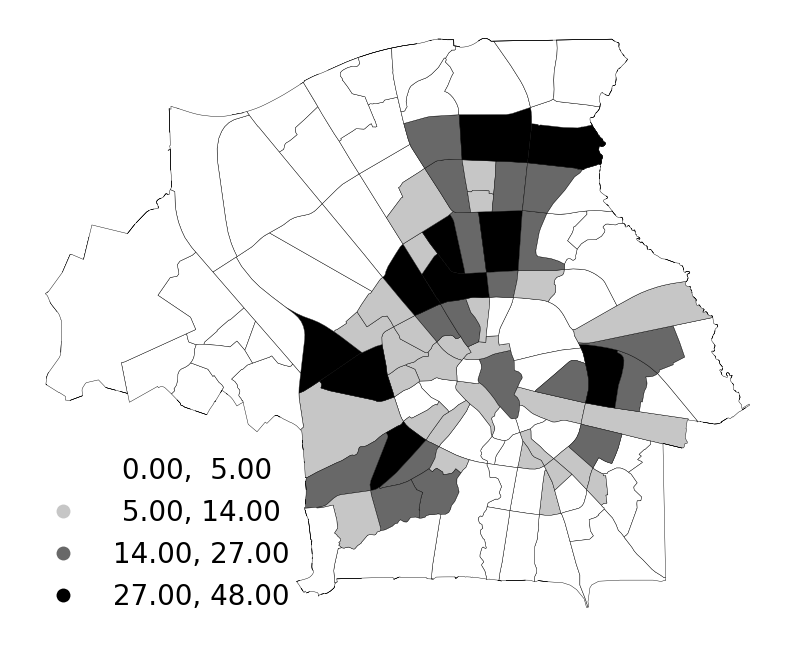

In [208]:
# Load neighbourhood polygons
neigh = gpd.read_file("Eindhoven_map/FC_Nieghbourhood_Eindhoven.shp")
neigh = neigh.to_crs("EPSG:28992")   # ensure meter-based CRS

# Load MC optimized stations
mc = pd.read_csv("MC_sites_selected_fixed_cost_.csv")

gdf_mc = gpd.GeoDataFrame(
    mc,
    geometry=gpd.points_from_xy(mc["POINT_X"], mc["POINT_Y"]),
    crs="EPSG:28992"
)

joined = gpd.sjoin(gdf_mc, neigh, how="left", predicate="within")

counts = joined.groupby("NAME").size()

neigh["MC_count"] = neigh["NAME"].map(counts).fillna(0).astype(int)

# -------------------------------
# Plot
# -------------------------------
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot first
neigh.plot(
    column="MC_count",
    cmap="Greys",
    linewidth=0.3,
    edgecolor="black",
    legend=True,
    scheme="NaturalBreaks",
    k=4,
    legend_kwds={
        "fontsize": 20,
        #"title": "Chargers",
        "frameon": False
    },
    ax=ax
)

# Get the legend object created by GeoPandas
leg = ax.get_legend()

# Move legend using axes fraction (not anchored)
leg.set_bbox_to_anchor((0.0, 0.0))   # x, y in axes fraction
leg.set_loc("lower left")


# -------------------------------
# North arrow (axes fraction)
# # -------------------------------
# ax.annotate(
#     "N",
#     xy=(0.08, 0.3),
#     xycoords="axes fraction",
#     ha="center",
#     va="bottom",
#     fontsize=18,
#     fontweight="bold",
#     zorder=10
# )
# ax.annotate(
#     "",
#     xy=(0.08, 0.5),
#     xytext=(0.08, 0.35),
#     xycoords="axes fraction",
#     arrowprops=dict(arrowstyle="-|>", lw=3, color="black"),
#     zorder=10
# )

# -------------------------------
#--------------------------
# Manual scale bar (map coords)
# # -------------------------------
# minx, miny, maxx, maxy = neigh.total_bounds

# bar_len = 2000   # meters (2 km)
# x0 = minx - 2000
# y0 = miny + 2300

# ax.plot(
#     [x0, x0 + bar_len],
#     [y0, y0],
#     color="black",
#     lw=3,
#     zorder=10
# )

# ax.text(
#     x0 + bar_len / 2,
#     y0 + 150,
#     "2 km",
#     ha="center",
#     va="bottom",
#     fontsize=14
# )

# -------------------------------
# Cosmetics
# -------------------------------
ax.set_axis_off()
ax.set_aspect("equal")

# plt.savefig("MC_chargers_by_neighborhood.png", dpi=600, bbox_inches="tight")
#plt.show()


#ax.axis("off")
plt.savefig("MC_Optimized_Chargers_per_Neighborhood.png", dpi=1200, bbox_inches='tight')
#plt.show()



In [89]:
print(neigh)

     Join_Count  TARGET_FID        ID                        NAME  TOTPOP_CY  \
0             0           1  07530011                     Breeven         71   
1             0           2  07530015                Buitengebied       1256   
2             0           3  07700409  Verspreide huizen Wintelre        726   
3            20           4  07721110                  Binnenstad       4166   
4             7           5  07721120                      Bergen       2878   
..          ...         ...       ...                         ...        ...   
133           0         134  08660009           Verspreide huizen        563   
134           0         135  16580009     Verspreide huizen Heeze        972   
135           0         136  17710001                     Skandia       3181   
136           0         137  17710004           Braakhuizen-Noord       4579   
137           0         138  17710009                  Gijzenrooi        154   

      AREA    j  ID_unique      POINT_X

FLOW BALANCING RESULTS

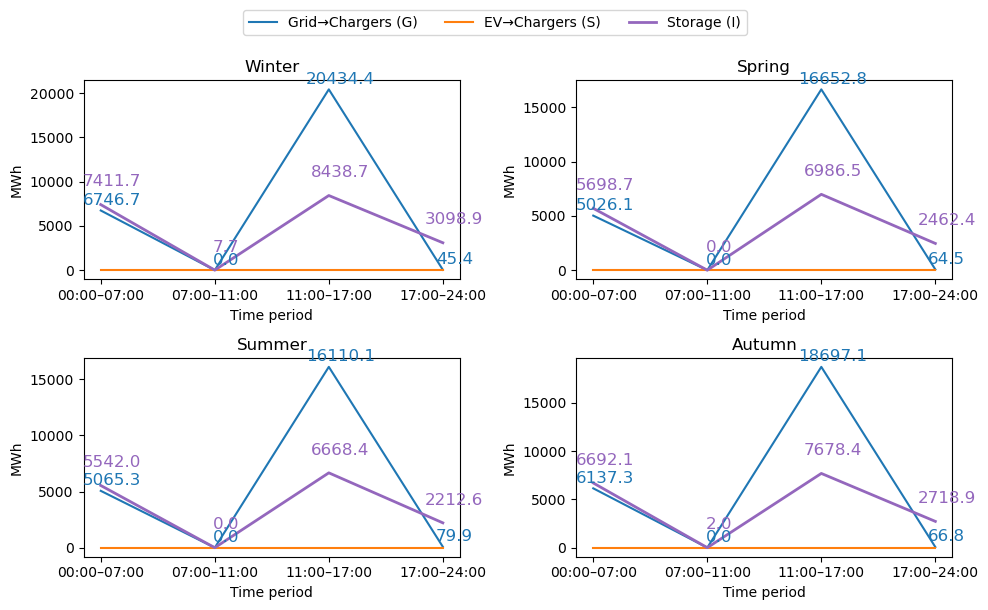

In [237]:
# Prepare 2x2 layout
df_temporal = pd.read_csv("MC_temporal_dynamics.csv")
seasons = sorted(df_temporal["m"].unique())

# Season labels
season_labels = {0: "Winter", 1: "Spring", 2: "Summer", 3: "Autumn"}

fig, axes = plt.subplots(2, 2, figsize=(10,6))
axes = axes.flatten()

for idx, m in enumerate(seasons[:4]):  # only first 4 if more exist
    d = df_temporal[df_temporal["m"] == m]
    ax = axes[idx]

    ax.plot(d["t"], d["grid_in_G"],  label="Grid→Chargers (G)", color="#1f77b4")
    ax.plot(d["t"], d["flow_S"],     label="EV→Chargers (S)",  color="#ff7f0e")
    ax.plot(d["t"], d["inventory_INV"], label="Storage (I)", color="#9467bd", linewidth=2)

    # Replace numeric ticks with time period labels
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels([
        "00:00–07:00",
        "07:00–11:00",
        "11:00–17:00",
        "17:00–24:00"
    ])

    ax.set_xlabel("Time period")
    ax.set_ylabel("MWh")
    ax.set_title(f"{season_labels.get(m, f'Season {m}')}")
    # relative offsets as a fraction of max seasonal value
    ymax = max(
        d["grid_in_G"].max(),
        d["flow_S"].max(),
        d["inventory_INV"].max()
    )

    offset_G   = 0.015 * ymax
    offset_S   = -0.03 * ymax
    offset_INV = 0.085 * ymax
    
    for x, y in zip(d["t"], d["grid_in_G"]):
        ax.text(x+ 0.1, y + offset_G, f"{y:.1f}",
                color="#1f77b4", fontsize=12, ha="center", va="bottom")
    
    # for x, y in zip(d["t"], d["flow_S"]):
    #     ax.text(x + 0.1, y + offset_S, f"{y:.3f}",
    #             color="#ff7f0e", fontsize=12, ha="center", va="top")
    
    for x, y in zip(d["t"], d["inventory_INV"]):
        ax.text(x + 0.1, y + offset_INV, f"{y:.1f}",
                color="#9467bd", fontsize=12, ha="center", va="bottom")
   

    # for x, y in zip(d["t"], d["grid_in_G"]):
    #     ax.text(x, y, f"{y:.1f}", color="#1f77b4", fontsize=10, ha="center", va="bottom")
    # for x, y in zip(d["t"], d["flow_S"]):
    #     ax.text(x, y, f"{y:.3f}", color="#ff7f0e", fontsize=10, ha="center", va="bottom")
    # for x, y in zip(d["t"], d["inventory_INV"]):
    #     ax.text(x, y, f"{y:.1f}", color="#9467bd", fontsize=10, ha="center", va="bottom")

# global legend once for all plots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("MC_S_G_and_I_comparison_by_seasion.png", dpi=1200, bbox_inches='tight')


In [98]:
print(df_temporal)

    m  t     grid_in_G  grid_out_Z  inventory_INV  flow_S      flow_X  \
0   0  0   6746.685260         0.0    7411.686049     0.0   29.390243   
1   0  1      0.000000         0.0       7.700000     0.0   86.817468   
2   0  2  20434.394606         0.0    8438.735363     0.0  141.327610   
3   0  3     45.429010         0.0    3098.937467     0.0   63.055905   
4   1  0   5026.142761         0.0    5698.700700     0.0   21.883628   
5   1  1      0.000000         0.0       0.000000     0.0   66.654152   
6   1  2  16652.753255         0.0    6986.506673     0.0  113.043554   
7   1  3     64.494663         0.0    2462.433297     0.0   54.257542   
8   2  0   5065.293687         0.0    5542.010976     0.0   21.311164   
9   2  1      0.000000         0.0       0.000000     0.0   64.862447   
10  2  2  16110.116015         0.0    6668.393512     0.0  110.493063   
11  2  3     79.940880         0.0    2212.602679     0.0   53.617256   
12  3  0   6137.250515         0.0    6692.138817  

In [21]:
seasons_df = pd.DataFrame(seasons)
print(seasons_df.head())

# Alternatively, if you just want to see the first few elements of the list
#print(seasons[:5])

   0
0  0
1  1
2  2
3  3


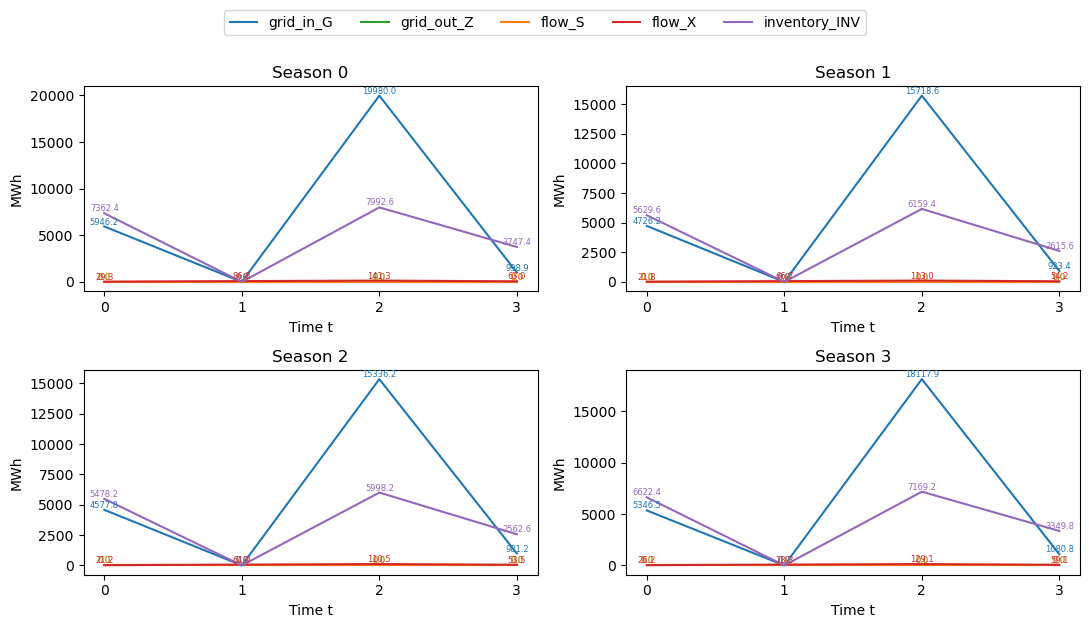

In [22]:
# Unique seasons
seasons = sorted(df_temporal["m"].unique())

# 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(11,6))
axes = axes.flatten()

colors = {
    "grid_in_G": "#1f77b4",   # blue
    "grid_out_Z": "#2ca02c",  # green
    "flow_S": "#ff7f0e",      # orange
    "flow_X": "#d62728",      # red
    "inventory_INV": "#9467bd" # purple
}

for idx, m in enumerate(seasons[:4]):  # only first 4 if more exist
    d = df_temporal[df_temporal["m"] == m]
    ax = axes[idx]

    # plot all flows
    for col, col_color in colors.items():
        ax.plot(d["t"], d[col], label=col, color=col_color)
        # annotate each time point
        for x, y in zip(d["t"], d[col]):
            ax.text(x, y, f"{y:.1f}", color=col_color, fontsize=6, ha="center", va="bottom")

    # four evenly spaced x-axis ticks
    xticks = np.linspace(d["t"].min(), d["t"].max(), 4, dtype=int)
    ax.set_xticks(xticks)

    ax.set_title(f"Season {m}")
    ax.set_xlabel("Time t")
    ax.set_ylabel("MWh")

# shared legend above plots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.05))

plt.tight_layout(rect=[0,0,1,0.97])
plt.show()



CHARGER UTILIZATION

In [180]:
path_EVCS_utilization = "MC_station_utilization.csv"
df_station = pd.read_csv(path_EVCS_utilization)

# Assume df_station has columns: station_j, lon, lat, total_energy_MWh
plt.figure(figsize=(6,6))
plt.scatter(df_station["lon"], df_station["lat"],
            s=df_station["total_energy_MWh"]*5,  # scale bubble size
            c=df_station["total_energy_MWh"],
            cmap="viridis", alpha=0.7)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of Station Energy Use")
plt.colorbar(label="Total Energy (MWh)")
plt.tight_layout()
plt.show()

KeyError: 'lon'

<Figure size 600x600 with 0 Axes>

STORAGE ANALYSIS RESULTS

In [24]:
df_inventory = pd.read_csv("FC_energy_network.csv")
print(df_inventory .columns)


Index(['demand_i', 'station_j', 'm', 't', 'flow_X', 'flow_S', 'grid_in_G',
       'grid_out_Z', 'inventory_INV', 'total_in', 'total_out'],
      dtype='object')


In [25]:
(df_inventory["flow_S"].abs() > 1e-9).sum()
df_inventory ["flow_S"].describe()


count    2743600.0
mean           0.0
std            0.0
min            0.0
25%            0.0
50%            0.0
75%            0.0
max            0.0
Name: flow_S, dtype: float64

In [ ]:
df_inventory = pd.read_csv("FC_energy_network.csv")
for m, d in df_inventory.groupby("m"):
    plt.figure(figsize=(7,3))
    for j, sub in d.groupby("station_j"):
        plt.plot(sub["t"], sub["inventory_INV"], label=f"Station {j}")
    plt.title(f"Season {m}: Storage Inventory Dynamics")
    plt.xlabel("Time t")
    plt.ylabel("Inventory(MWh)")
    plt.legend(ncol=2, fontsize=7)
    plt.figure(figsize=(7,3), constrained_layout=True)
    plt.show()

In [27]:
from IPython.display import display
df_perf=pd.read_csv("FC_model_performance.csv")
display(df_perf.style.format({
    "Objective":"{:.2f}",
    "BestBound":"{:.2f}",
    "Gap":"{:.2%}",
    "Runtime_s":"{:.3f}",
    "Vars_total":"{:.0f}",
    "Constr_total":"{:.0f}"
}))


,Objective,BestBound,Gap,Runtime_s,Vars_total,Constr_total,Chargers_opened
0,32600336.82,32447667.29,0.47%,1578.575,5592920,136035,1076


In [28]:
print(df_perf)

      Objective     BestBound       Gap    Runtime_s  Vars_total  \
0  3.260034e+07  3.244767e+07  0.004683  1578.574837     5592920   

   Constr_total  Chargers_opened  
0        136035             1076  


In [29]:
!jupyter kernelspec list


Available kernels:
  python3    C:\Users\Katon002\AppData\Roaming\Python\share\jupyter\kernels\python3


In [30]:
df_inv= pd.read_csv("FC_inventory_timeseries.csv")
df_inv.groupby(["station_j", "m"])["inventory_MWh"].mean().unstack().round(2)

print(df_inv)

      station_j  m  t  inventory_MWh
0             0  0  0          0.088
1             0  0  2          0.088
2             0  0  3          0.088
3             0  3  0          0.088
4             0  3  2          0.088
...         ... .. ..            ...
8457       2032  2  2          0.088
8458       2032  2  3          0.088
8459       2032  3  0          0.088
8460       2032  3  2          0.088
8461       2032  3  3          0.088

[8462 rows x 4 columns]


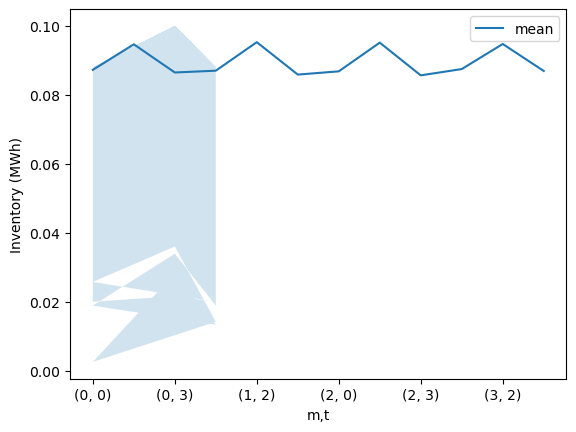

In [31]:
df_summary = df_inv.groupby(["m", "t"])["inventory_MWh"].agg(["mean", "min", "max"])
df_summary.plot(y=["mean"], ylabel="Inventory (MWh)")
plt.fill_between(df_summary.index.get_level_values("t"),
                 df_summary["min"], df_summary["max"], alpha=0.2)


C:\Users\Katon002\AppData\Local\Temp\ipykernel_2388\2126474396.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["00:00–07:00", "07:00–11:00", "11:00–17:00", "17:00–23:00"], fontsize=11)
C:\Users\Katon002\AppData\Local\Temp\ipykernel_2388\2126474396.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["00:00–07:00", "07:00–11:00", "11:00–17:00", "17:00–23:00"], fontsize=11)


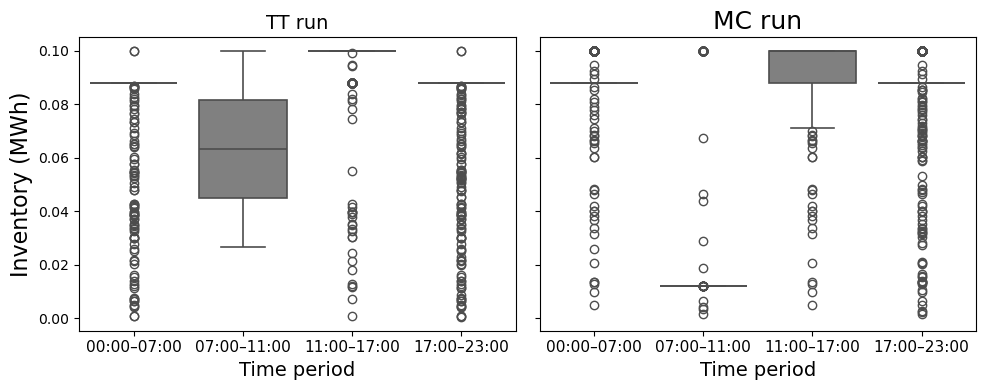

In [220]:
df_inv_TT = pd.read_csv("MC_inventory_timeseries.csv")
df_inv_FC = pd.read_csv("TT_inventory_timeseries.csv")

# Ensure all expected time values exist
for df in [df_inv_TT, df_inv_FC]:
    df["t"] = df["t"].astype(int)
    df.set_index("t", inplace=True)
    for t in [0, 1, 2, 3]:
        if t not in df.index:
            df.loc[t] = {"inventory_MWh": None}
    df.reset_index(inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

sns.boxplot(x="t", y="inventory_MWh", data=df_inv_TT,
            color="grey", linewidth=1.2, ax=axes[0])
axes[0].set_title("TT run", fontsize=14)
axes[0].set_xlabel("Time period", fontsize=14)
axes[0].set_ylabel("Inventory (MWh)", fontsize=16)
axes[0].set_xticklabels(["00:00–07:00", "07:00–11:00", "11:00–17:00", "17:00–23:00"], fontsize=11)

sns.boxplot(x="t", y="inventory_MWh", data=df_inv_FC,
            color="grey", linewidth=1.2, ax=axes[1])
axes[1].set_title("MC run", fontsize=18)
axes[1].set_xlabel("Time period", fontsize=14)
axes[1].set_ylabel("", fontsize=18)
axes[1].set_xticklabels(["00:00–07:00", "07:00–11:00", "11:00–17:00", "17:00–23:00"], fontsize=11)

plt.tight_layout()
#plt.savefig("Storage_FC_TT", dpi=600, bbox_inches='tight')

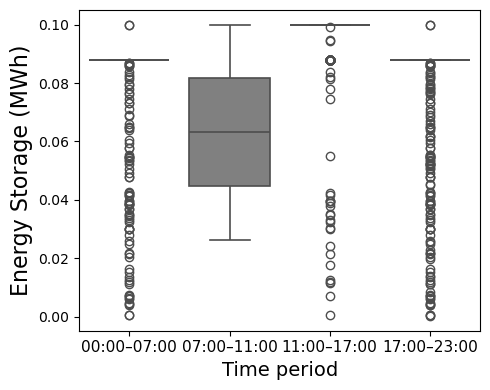

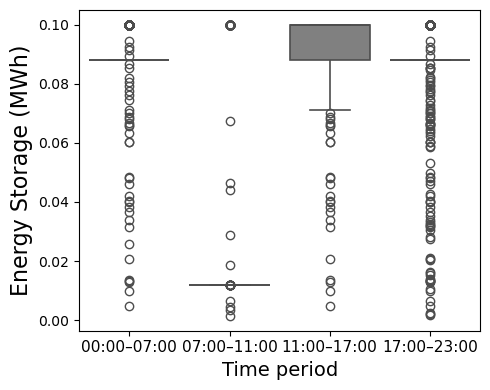

In [224]:
# -------------------------------
# TT run figure
# -------------------------------
plt.figure(figsize=(5, 4))
sns.boxplot(
    x="t",
    y="inventory_MWh",
    data=df_inv_TT,
    color="grey",
    linewidth=1.2
)
#plt.title("TT run", fontsize=16)
plt.xlabel("Time period", fontsize=14)
plt.ylabel("Energy Storage (MWh)", fontsize=16)
plt.xticks(
    ticks=[0, 1, 2, 3],
    labels=["00:00–07:00", "07:00–11:00", "11:00–17:00", "17:00–23:00"],
    fontsize=11
)
plt.tight_layout()
plt.savefig("Storage_TT_run.png", dpi=600, bbox_inches="tight")
plt.show()


# -------------------------------
# MC run figure
# -------------------------------
plt.figure(figsize=(5, 4))
sns.boxplot(
    x="t",
    y="inventory_MWh",
    data=df_inv_FC,
    color="grey",
    linewidth=1.2
)
#plt.title("MC run", fontsize=16)
plt.xlabel("Time period", fontsize=14)
plt.ylabel("Energy Storage (MWh)", fontsize=16)
plt.xticks(
    ticks=[0, 1, 2, 3],
    labels=["00:00–07:00", "07:00–11:00", "11:00–17:00", "17:00–23:00"],
    fontsize=11
)
plt.tight_layout()
plt.savefig("MC_Storage.png", dpi=600, bbox_inches="tight")
plt.show()


In [ ]:


def boxplot_stats(df, name):
    print(f"\nBoxplot statistics for {name}:")
    for t in [0, 1, 2, 3]:
        values = df[df["t"] == t]["inventory_MWh"].dropna()  # Raw numbers used
        if len(values) == 0:
            print(f"  t={t} ({['00:00–07:00', '07:00–11:00', '11:00–17:00', '17:00–23:00'][t]}): No data")
            continue
        print(f"  t={t} ({['00:00–07:00', '07:00–11:00', '11:00–17:00', '17:00–23:00'][t]}):")
        print(f"    Count: {len(values)}")
        print(f"    Mean: {values.mean():.2f}")
        print(f"    Min: {values.min():.2f} | Max: {values.max():.2f}")
        print(f"    5th %ile (low whisker): {np.percentile(values, 5):.2f}")
        print(f"    Q1 (25th): {np.percentile(values, 25):.2f}")
        print(f"    Median (50th): {np.median(values):.2f}")
        print(f"    Q3 (75th): {np.percentile(values, 75):.2f}")
        print(f"    95th %ile (high whisker): {np.percentile(values, 95):.2f}")

boxplot_stats(df_inv_TT, "TT run (MC_inventory_timeseries.csv)")
boxplot_stats(df_inv_FC, "FC run (TT_inventory_timeseries.csv)")

In [43]:
df_inv_FC[df_inv_FC["t"] == 1]

,t,station_j,m,inventory_MWh
8416,1,2014,2,0.1


In [34]:
df_base = pd.read_csv("Charger_in_eindhoven.csv")
df_opt  = pd.read_csv("FC_sites_selected_fixed_cost_.csv")
print(df_base.columns)
print(df_inv_TT)

Index(['OBJECTID', 'Join_Count', 'TARGET_FID', 'Join_Count_1', 'TARGET_FID_1',
       'CID', 'DependeVar', 'amenity', 'name', 'operator', 'brand', 'ID_unque',
       'Parking_Location', 'NEAR_FID', 'Train_station', 'Gas_station',
       'CarRental', 'BusStation', 'Hospital', 'EatingDrinking', 'RoadNetwork',
       'PowerNetwork', 'obsvalue', 'categorie', 'POINT_X', 'POINT_Y',
       'RASTERVALU'],
      dtype='object')


NameError: name 'df_inv_TT' is not defined

In [2]:
# Load files
df_base = pd.read_csv("Charger_in_eindhoven.csv")
#df_opt  = pd.read_csv("FC_sites_selected_fixed_cost_.csv")

df_opt =pd.read_csv("MC_sites_selected_fixed_cost_.csv")
df_opt_TT =pd.read_csv("TT_run_sites_selected_.csv")

In [3]:
# # --- Load CSVs ---
# df_base = pd.read_csv("Charger_in_eindhoven.csv")
# df_opt  = pd.read_csv("FC_sites_selected_fixed_cost_.csv")

# --- Load Eindhoven shapefile ---
boundary = gpd.read_file("Eindhoven_map/Eindhovenmap.shp")


# --- Convert baseline & optimized to GeoDataFrames ---
gdf_base = gpd.GeoDataFrame(df_base, geometry=gpd.points_from_xy(df_base["POINT_X"], df_base["POINT_Y"]), crs=boundary.crs)
gdf_opt  = gpd.GeoDataFrame(df_opt,  geometry=gpd.points_from_xy(df_opt["POINT_X"],  df_opt["POINT_Y"]),  crs=boundary.crs)


In [4]:
dist_matrix = cdist(df_opt[["POINT_X","POINT_Y"]], df_base[["POINT_X","POINT_Y"]])
nearest = dist_matrix.min(axis=1)

print("Number of optimized chargers:", len(df_opt))
print("Average relocation distance (m):", nearest.mean())
print("Median relocation distance (m):", np.median(nearest))
print("Max relocation distance (m):", nearest.max())


Number of optimized chargers: 1071
Average relocation distance (m): 277.288669655844
Median relocation distance (m): 247.99321224633923
Max relocation distance (m): 887.1471892399709


In [5]:
print("Baseline stations:", len(df_base))
print("Optimized stations:", len(df_opt))
print("Change in count:", len(df_opt) - len(df_base))


Baseline stations: 158
Optimized stations: 1071
Change in count: 913


In [75]:
def nearest_distances(df_from, df_to, xcol="POINT_X", ycol="POINT_Y"):
    A = df_from[[xcol, ycol]].to_numpy(dtype=float)
    B = df_to[[xcol, ycol]].to_numpy(dtype=float)
    D = cdist(A, B)                         # shape: len(A) × len(B)
    return D.min(axis=1)                    # nearest neighbor distance for each row in A

def summarize(d):
    d = np.asarray(d, dtype=float)
    return {
        "n": d.size,
        "mean": float(d.mean()),
        "median": float(np.median(d)),
        "p90": float(np.percentile(d, 90)),
        "p95": float(np.percentile(d, 95)),
        "iqr": float(np.percentile(d, 75) - np.percentile(d, 25)),
        "max": float(d.max()),
    }

# Baseline → TT
dist_base_tt = nearest_distances(df_base, df_opt_TT)
stats_base_tt = summarize(dist_base_tt)

# Baseline → MC
dist_base_mc = nearest_distances(df_base, df_opt_MC)
stats_base_mc = summarize(dist_base_mc)

# TT → MC and MC → TT
dist_tt_to_mc = nearest_distances(df_opt_TT, df_opt_MC)
dist_mc_to_tt = nearest_distances(df_opt_MC, df_opt_TT)
stats_tt_to_mc = summarize(dist_tt_to_mc)
stats_mc_to_tt = summarize(dist_mc_to_tt)

# Inspect
pd.DataFrame.from_dict(
    {
        "Baseline→TT": stats_base_tt,
        "Baseline→MC": stats_base_mc,
        "TT→MC": stats_tt_to_mc,
        "MC→TT": stats_mc_to_tt,
    },
    orient="index"
)

,n,mean,median,p90,p95,iqr,max
Baseline→TT,158,127.921838,92.351462,270.371435,325.455575,126.834377,516.273381
Baseline→MC,158,109.049443,77.312415,244.222622,282.088313,100.171032,470.335271
TT→MC,1071,27.882117,0.000000,115.182239,170.774017,0.000000,516.467093
MC→TT,1071,25.512964,0.000000,110.276409,143.838807,0.000000,538.038601


NameError: name 'Line2D' is not defined

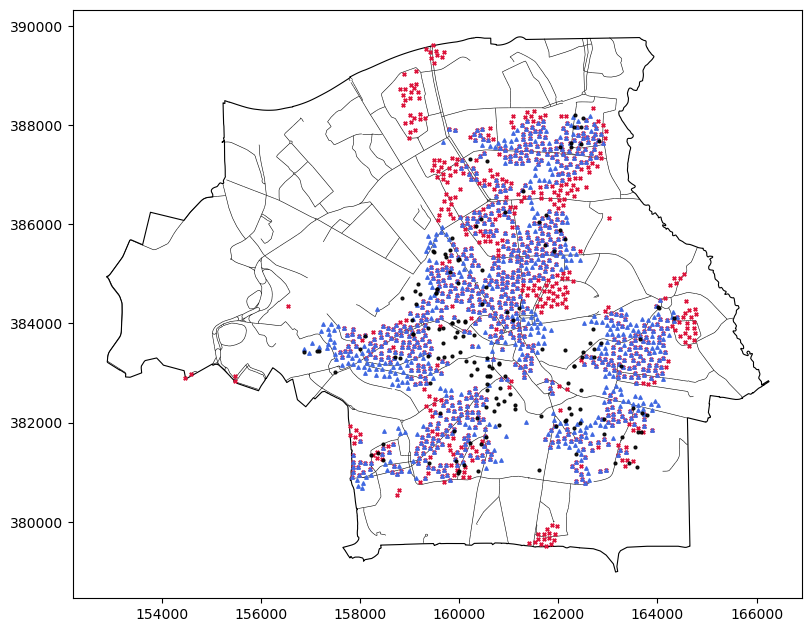

In [3]:
# -------------------------------
# Load data
# -------------------------------
df_base   = pd.read_csv("Charger_in_eindhoven.csv")
df_opt_MC = pd.read_csv("MC_sites_selected_fixed_cost_.csv")
df_opt_MC = pd.read_csv("Prob_three_phase_sites_selected.csv")
df_opt_TT = pd.read_csv("TT_run_sites_selected_.csv")

boundary  = gpd.read_file("Eindhoven_map/Eindhovenmap.shp")
road_net  = gpd.read_file("Road_layer.shp")

# Clip roads to boundary for a clean map
road_net = gpd.overlay(road_net, boundary, how="intersection")

# GeoDataFrames
gdf_base = gpd.GeoDataFrame(
    df_base, geometry=gpd.points_from_xy(df_base["POINT_X"], df_base["POINT_Y"]), crs=boundary.crs
)
gdf_MC = gpd.GeoDataFrame(
    df_opt_MC, geometry=gpd.points_from_xy(df_opt_MC["POINT_X"], df_opt_MC["POINT_Y"]), crs=boundary.crs
)
gdf_TT = gpd.GeoDataFrame(
    df_opt_TT, geometry=gpd.points_from_xy(df_opt_TT["POINT_X"], df_opt_TT["POINT_Y"]), crs=boundary.crs
)

# -------------------------------
# Relocation distances (optimized → nearest existing)
# -------------------------------
base_xy = df_base[["POINT_X", "POINT_Y"]].to_numpy()
mc_xy   = df_opt_MC[["POINT_X", "POINT_Y"]].to_numpy()
tt_xy   = df_opt_TT[["POINT_X", "POINT_Y"]].to_numpy()

dist_MC = cdist(mc_xy, base_xy).min(axis=1)
dist_TT = cdist(tt_xy, base_xy).min(axis=1)

# -------------------------------
# Plot
# -------------------------------
fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)

# Base layers
boundary.plot(ax=ax, color="white", edgecolor="black", linewidth=0.8, zorder=1)
road_net.plot(ax=ax, color="black", linewidth=0.4, zorder=2)

# Chargers
gdf_base.plot(ax=ax, color="black",     markersize=4, alpha=0.9, zorder=5)
gdf_MC.plot(ax=ax,   color="crimson",   markersize=6, marker="x", zorder=4)
gdf_TT.plot(ax=ax,   color="royalblue", markersize=6, marker="^", zorder=4)

# -------------------------------
# Legend proxies
# -------------------------------
handles = [
    Line2D([0], [0], color="black", linewidth=1.2, label="Road network"),
    Line2D([0], [0], marker="o", color="black", markersize=6, linestyle="None", label="Baseline chargers"),
    Line2D([0], [0], marker="x", color="crimson", markersize=7, linestyle="None", label="MC run chargers"),
    Line2D([0], [0], marker="^", color="royalblue", markersize=7, linestyle="None", label="TT run chargers"),
]

# -------------------------------
# Legend bottom-right (inside map)
# -------------------------------
leg = ax.legend(
    handles=handles,
    loc="lower right",
    bbox_to_anchor=(1.05, -0.12),
    frameon=False,
    fontsize=12
)
leg.get_frame().set_edgecolor("grey")
leg.get_frame().set_linewidth(0.8)

# -------------------------------

# -------------------------------
# --- Manual scale bar (x-only control) ---
minx, miny, maxx, maxy = boundary.total_bounds

bar_len = 2000  # meters
x0 = maxx - 200    # move right by increasing this value
y0 = miny + 500    # keep y fixed (same vertical position)

ax.plot([x0, x0 + bar_len], [y0, y0], color="black", lw=3, zorder=10)
ax.text(
    x0 + bar_len / 2,
    y0 + 120,
    "2 km",
    ha="center",
    va="bottom",
    fontsize=12
)

# -------------------------------
# North arrow above scale bar (axes fraction)
# -------------------------------
ax.annotate(
    "N",
    xy=(1.0, 0.08),
    xycoords="axes fraction",
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold",
    zorder=10
)
ax.annotate(
    "",
    xy=(1.0, 0.25),
    xytext=(1.0, 0.1),
    xycoords="axes fraction",
    arrowprops=dict(arrowstyle="-|>", lw=2.5, color="black"),
    zorder=10
)

# -------------------------------
# Inset: relocation distance distributions (TT vs MC)
# -------------------------------
inset_ax = inset_axes(
    ax,
    width="40%",
    height="25%",
    bbox_to_anchor=(-0.05, -0.1, 1, 1),  # x, y, w, h (w,h can be 1,1)
    bbox_transform=ax.transAxes,
    loc="lower left",
    borderpad=0.1
)

#inset_ax = inset_axes(ax, width="40%",  bbox_to_anchor=(0.02, 0.55), height="25%", loc="lower left", borderpad=0.1)
bins = 30
inset_ax.hist(dist_MC, bins=bins, color="crimson", alpha=0.55, label="MC → baseline")
inset_ax.hist(dist_TT, bins=bins, color="royalblue", alpha=0.55, label="TT → baseline")
inset_ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.2, 0.6),
    frameon=True,
    facecolor="none",
    edgecolor="grey",
    fontsize=12
)

for spine in ("top", "right"):
    inset_ax.spines[spine].set_visible(False)

inset_ax.set_facecolor("none")
inset_ax.set_xlabel("Distance (m)", fontsize=12)
inset_ax.set_ylabel("No. EVCS", fontsize=12)
inset_ax.set_title("Relocation distance", fontsize=12)
inset_ax.tick_params(axis="both", labelsize=12)

# -------------------------------
# Cosmetics
# -------------------------------
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")

# Save / show
plt.savefig("baseline_vs_TT_MC_relocation.png", dpi=1200, bbox_inches="tight")
#plt.show()